In [3]:
import torch
import torch.nn as nn
import os
import json
import pandas as pd
from pprint import pprint
from models.queryner_teacher import QueryNERTeacher
from models.crf_layer import CRFOutputLayer
from models.base_model import BaseNERModel
from models.distilbert_student import DistilBERTStudent
from models.tinybert_student import TinyBERTStudent
from models.bilstm_student import BiLSTMStudent
from models.ner_dataset import NERDataset
from models.utils import load_label_info, create_dataloaders

from seqeval.metrics import classification_report
from seqeval.metrics import accuracy_score, f1_score, precision_score, recall_score
from seqeval.scheme import IOB1, IOB2

In [4]:
def load_json_to_df(json_path):
    with open(json_path) as file:
        data = json.load(file)
    df = pd.DataFrame(data=data["successful_experiments"])
    df.insert(0, "id", df.index + 1)
    return df

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

label_info = load_label_info("bltlab/queryner-augmented-data-bert-base-uncased")

tokenizer, train_loader, val_loader, test_loader = create_dataloaders(
    train_path=r"D:\Dafa\Project\queryner-kd\data\processed\train.json",
    val_path=r"D:\Dafa\Project\queryner-kd\data\processed\validation.json",
    test_path=r"D:\Dafa\Project\queryner-kd\data\processed\test.json",
    model_name="bert-base-uncased",
    batch_size=16,
    max_length=128
)

cuda


In [6]:
models_name = [
    'bilstm-crf.pt',
                'bilstm-nocrf.pt',
                'distilbert-crf.pt',
                'distilbert-nocrf.pt',
                'teacher-crf.pt',
                'teacher-nocrf.pt',
                'tinybert-crf.pt',
                'tinybert-nocrf.pt']

models_name_without_pt = [name.split(".")[0] for name in models_name]

## Run Inference All Models

In [ ]:
model_folder_path = r"D:\Dafa\Project\queryner-kd\checkpoints\models-baseline"

In [206]:
def instantiate_student(model_class, model_path, label_info, use_crf, device):
    if model_class == "DistilBERTStudent":
        model = DistilBERTStudent(
            model_name=model_path,
            label_info=label_info,
            use_crf=use_crf,
        )
    elif model_class == "TinyBertStudent":
        model = TinyBERTStudent(
            model_name=model_path,
            label_info=label_info,
            use_crf=use_crf,
        )
    elif model_class == "BiLSTMStudent":
        model = BiLSTMStudent(
            num_labels=35,
            use_crf=use_crf,
            model_name_for_vocab=model_path,
            label_info=label_info,
            emb_dim=768
        )
    else:
        raise ValueError(model_class)
    return model.to(device)


def instantiate_teacher(model_class, model_path, label_info, use_crf, device):
    if model_class == "QueryNERTeacher":
        model = QueryNERTeacher(
            model_name=model_path,
            label_info=label_info,
            use_crf=use_crf,
        )
    else:
        raise ValueError(model_class)
    return model.to(device)


def load_student_model(checkpoint_path, model_class, model_path, label_info, use_crf, device):
    model = instantiate_student(model_class, model_path, label_info, use_crf, device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()
    return model

def load_teacher_model(checkpoint_path, model_class, model_path, label_info, use_crf, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    teacher = instantiate_teacher(model_class, model_path, label_info, use_crf, device)
    teacher.load_state_dict(checkpoint["model_state_dict"])
    teacher.to(device)
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False
    return teacher

def load_all_models(models_name, model_folder_path, label_info, device):
    loaded = {}
    for name in models_name:
        path = os.path.join(model_folder_path, name)
        if "teacher" in name:
            use_crf = "-crf" in name
            loaded[name.split(".")[0]] = load_teacher_model(
                path,
                "QueryNERTeacher",
                "bert-base-uncased",
                label_info,
                use_crf,
                device,
            )
        elif "distilbert" in name:
            use_crf = "-crf" in name
            loaded[name.split(".")[0]] = load_student_model(
                path,
                "DistilBERTStudent",
                "distilbert-base-uncased",
                label_info,
                use_crf,
                device,
            )
        elif "tinybert" in name:
            use_crf = "-crf" in name
            loaded[name.split(".")[0]] = load_student_model(
                path,
                "TinyBertStudent",
                "huawei-noah/TinyBERT_General_4L_312D",
                label_info,
                use_crf,
                device,
            )
        elif "bilstm" in name:
            use_crf = "-crf" in name
            loaded[name.split(".")[0]] = load_student_model(
                path,
                "BiLSTMStudent",
                "bert-base-uncased",
                label_info,
                use_crf,
                device
            )
    return loaded

In [207]:
models = load_all_models(models_name, model_folder_path, label_info, device)

In [208]:
def predict(model, encoding, device):
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    return outputs["pred"]

In [209]:
def decode_word_preds(pred_ids, word_ids):
    word_preds = []
    prev_word = None

    for wid, pid in zip(word_ids, pred_ids):

        if wid is None:
            continue

        if wid != prev_word:

            if isinstance(pid, torch.Tensor):
                pid = pid.item()

            word_preds.append(int(pid))

        prev_word = wid

    return word_preds

In [210]:
def run_inference_models(models, dataloader, device):
    results = []

    for batch in dataloader:

        batch_preds = {}

        for name, model in models.items():
            batch_preds[name] = predict(model, batch, device)

        for i in range(len(batch["tokens"])):

            tokens = batch["tokens"][i]
            gold = batch["ner_tags"][i]
            word_ids = batch["word_ids"][i]

            entry = {
                "tokens": tokens,
                "gold": gold
            }

            for name, preds in batch_preds.items():
                pred_ids = preds[i]
                entry[name] = decode_word_preds(pred_ids, word_ids)

            results.append(entry)

    return results

In [211]:
results = run_inference_models(models, test_loader, device)

In [ ]:
# with open(r"D:\Dafa\Project\queryner-kd\result-data\qualitative\baseline\qualitative_results_baseline.json", "w") as f:
#     json.dump(results, f, indent=4)

## Map Labels, Create Gold and Predicted Labels Lists

In [7]:
import json

In [8]:
json_path = r"D:\Dafa\Project\queryner-kd\result-data\qualitative\qualitative_results_kd1e5.json"

with open(json_path, "r") as file:
    results = json.load(file)

In [9]:
def map_id_to_label(pred_ids, id2label):
    return [id2label[int(pid)] for pid in pred_ids]

models_name_without_pt = [name.split(".")[0] for name in models_name]
results_label = []

for entry in results:
    new_entry = {
        "tokens": entry["tokens"],
        "gold": map_id_to_label(entry["gold"], label_info["id2label"])
    }
    for model in models_name_without_pt:
        new_entry[model] = map_id_to_label(entry[model], label_info["id2label"])
    results_label.append(new_entry)

In [10]:
# with open(r"D:\Dafa\Project\queryner-kd\result-data\qualitative\baseline\qualitative_results_label_baseline.json", "w") as file:
#     # results_label = json.load(file)
#     json.dump(results_label, file, indent=4)

In [10]:
gold_labels = [entry["gold"] for entry in results_label]
pred_labels = {model: [entry[model] for entry in results_label] for model in models_name_without_pt}

## Token-Level Evaluation

### Entity Based Acc, Precision, Recall, F1 Scores

In [24]:
entity_based_scores = {}

for model in models_name_without_pt:
    entity_based_scores[model] = {
        "accuracy_score": accuracy_score(gold_labels, pred_labels[model])*100,
        "precision": precision_score(gold_labels, pred_labels[model], mode="strict", scheme=IOB2)*100,
        "recall": recall_score(gold_labels, pred_labels[model], mode="strict", scheme=IOB2)*100,
        "f1": f1_score(gold_labels, pred_labels[model], mode="strict", scheme=IOB2)*100
    }

In [25]:
df_scores = pd.DataFrame.from_dict(entity_based_scores, orient="index")
df_scores = df_scores.reset_index().rename(columns={"index": "model"})
df_scores

,model,accuracy_score,precision,recall,f1
0,bilstm-crf,57.224959,53.542234,50.191571,51.812788
1,bilstm-nocrf,57.799672,52.775291,50.191571,51.451015
2,distilbert-crf,66.037219,61.723535,60.068114,60.884574
3,distilbert-nocrf,66.392994,62.143171,60.238399,61.175962
4,teacher-crf,65.681445,62.466368,59.301831,60.842979
5,teacher-nocrf,65.845649,62.618510,59.046403,60.780018
6,tinybert-crf,61.631089,56.391982,53.895275,55.115368
7,tinybert-nocrf,62.917351,58.109319,55.214985,56.625191


In [ ]:
# df_scores.to_csv(r"D:\Dafa\Project\queryner-kd\result-data\entity-based-eval\scores_no_scheme.csv", index=False)

### Check I- without preceding B-

In [27]:
def check_I_entity(gold_labels):
    i_without_b = 0
    for sentence in gold_labels:
        for i, label in enumerate(sentence):
            if label.startswith("I-"):
                if i == 0 or not sentence[i-1].endswith(label[2:]):
                    i_without_b += 1
    return i_without_b

In [28]:
i_without_b = {}

for model in models_name_without_pt:
    i_without_b[model] = check_I_entity(pred_labels[model])
    print(f"Total I- tags without preceding B- tags for {model}: {i_without_b[model]}")
    print("==" * 20)

Total I- tags without preceding B- tags for bilstm-crf: 84
Total I- tags without preceding B- tags for bilstm-nocrf: 213
Total I- tags without preceding B- tags for distilbert-crf: 119
Total I- tags without preceding B- tags for distilbert-nocrf: 96
Total I- tags without preceding B- tags for teacher-crf: 127
Total I- tags without preceding B- tags for teacher-nocrf: 139
Total I- tags without preceding B- tags for tinybert-crf: 177
Total I- tags without preceding B- tags for tinybert-nocrf: 170


In [29]:
df_i_without_b = pd.DataFrame.from_dict(i_without_b, orient="index", columns=["I_without_B"])
df_i_without_b = df_i_without_b.reset_index().rename(columns={"index": "model"})
df_i_without_b["invalid bio rate"] = df_i_without_b["I_without_B"] / 3654
df_i_without_b

,model,I_without_B,invalid bio rate
0,bilstm-crf,84,0.022989
1,bilstm-nocrf,213,0.058292
2,distilbert-crf,119,0.032567
3,distilbert-nocrf,96,0.026273
4,teacher-crf,127,0.034756
5,teacher-nocrf,139,0.038041
6,tinybert-crf,177,0.048440
7,tinybert-nocrf,170,0.046524


In [30]:
# give me num of all tokens in each model

for model in models_name_without_pt:
    total_tokens = sum(len(entry[model]) for entry in results_label)
    print(f"Total tokens for {model}: {total_tokens}")

Total tokens for bilstm-crf: 3654
Total tokens for bilstm-nocrf: 3654
Total tokens for distilbert-crf: 3654
Total tokens for distilbert-nocrf: 3654
Total tokens for teacher-crf: 3654
Total tokens for teacher-nocrf: 3654
Total tokens for tinybert-crf: 3654
Total tokens for tinybert-nocrf: 3654


In [31]:
# df_i_without_b.to_csv(r"D:\Dafa\Project\queryner-kd\result-data\entity-based-eval\i_without_b.csv", index=False)

### Classification Report

In [32]:
# report = classification_report(gold_labels, pred_labels["teacher-crf"], output_dict=True, mode="strict", scheme=IOB2)

In [11]:
reports_path = r"D:\Dafa\Project\queryner-kd\result-data\entity-based-eval\reports"

# for model in models_name_without_pt:
#     report = classification_report(gold_labels, pred_labels[model], output_dict=True, mode="strict", scheme=IOB2)
#     report_df = pd.DataFrame(report).transpose()
#     report_df = report_df.reset_index().rename(columns={"index": "label"})
#     report_df.to_csv(os.path.join(reports_path, f"{model}_report.csv"), index=False)

In [12]:
cls_reports = {}

for model in models_name_without_pt:
    report = classification_report(gold_labels, pred_labels[model], output_dict=True, mode="strict", scheme=IOB2)
    cls_reports[model] = report

c:\Users\user\anaconda3\envs\gnn\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [13]:
def cls_report_to_df(report, model_name, crf_type):
    rows = []
    
    for entity, values in report.items():
        if entity in ["micro avg", "macro avg", "weighted avg"]:
            continue
            
        rows.append({
            "model": model_name,
            "crf_type": crf_type,
            "entity": entity,
            "precision": values["precision"],
            "recall": values["recall"],
            "f1": values["f1-score"],
            "support": values["support"]
        })
        
    return pd.DataFrame(rows)

In [15]:
df_entities = pd.concat([
    cls_report_to_df(cls_reports["bilstm-crf"], "bilstm", "crf"),
    cls_report_to_df(cls_reports["bilstm-nocrf"], "bilstm", "nocrf"),
    cls_report_to_df(cls_reports["distilbert-crf"], "distilbert", "crf"),
    cls_report_to_df(cls_reports["distilbert-nocrf"], "distilbert", "nocrf"),
    cls_report_to_df(cls_reports["tinybert-crf"], "tinybert", "crf"),
    cls_report_to_df(cls_reports["tinybert-nocrf"], "tinybert", "nocrf"),
    cls_report_to_df(cls_reports["teacher-crf"], "teacher", "crf"),
    cls_report_to_df(cls_reports["teacher-nocrf"], "teacher", "nocrf"),
])

In [16]:
df_entities

,model,crf_type,entity,precision,recall,f1,support
0,bilstm,crf,UoM,0.678571,0.640449,0.658960,89
1,bilstm,crf,color,0.735294,0.602410,0.662252,83
2,bilstm,crf,condition,0.272727,0.409091,0.327273,22
3,bilstm,crf,content,0.312977,0.359649,0.334694,114
4,bilstm,crf,core_product_type,0.616071,0.620922,0.618487,889
...,...,...,...,...,...,...,...
12,teacher,nocrf,product_name,0.438095,0.353846,0.391489,130
13,teacher,nocrf,product_number,0.000000,0.000000,0.000000,4
14,teacher,nocrf,quantity,0.666667,0.166667,0.266667,12
15,teacher,nocrf,shape,0.392157,0.487805,0.434783,41


### Entity Comparation

In [17]:
df_entities["f1"] = df_entities["f1"].apply(lambda x: x*100)
df_entities["f1"] = df_entities["f1"].round(2)

In [18]:
df_entities["f1"] = df_entities["f1"].round(2)

In [19]:
entity_crf_compare = (
    df_entities
    .groupby(["entity", "crf_type"])
    ["f1"]
    .mean()
    .unstack()
)

entity_crf_compare["delta_crf"] = (
    entity_crf_compare["crf"] - entity_crf_compare["nocrf"]
)

In [20]:
df_entities[df_entities["model"] != "teacher"].groupby(["entity", "crf_type"])["f1"].mean().unstack()

crf_type,crf,nocrf
entity,,
UoM,69.740000,73.026667
color,64.913333,65.000000
condition,33.566667,37.653333
content,44.506667,46.650000
core_product_type,66.200000,66.240000
creator,52.786667,54.893333
department,54.300000,53.300000
material,57.750000,57.113333
modifier,46.546667,45.443333


In [21]:
entity_crf_compare

crf_type,crf,nocrf,delta_crf
entity,,,
UoM,70.9825,73.9375,-2.9550
color,66.9275,66.7500,0.1775
condition,37.8875,40.5350,-2.6475
content,48.2925,49.2725,-0.9800
core_product_type,67.5900,67.2725,0.3175
creator,54.8825,56.5550,-1.6725
department,54.1275,53.5975,0.5300
material,59.0000,60.8350,-1.8350
modifier,46.8650,46.1700,0.6950


In [22]:
classification_report(gold_labels, pred_labels["bilstm-crf"], output_dict=True)

c:\Users\user\anaconda3\envs\gnn\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'UoM': {'precision': 0.6551724137931034,
  'recall': 0.6404494382022472,
  'f1-score': 0.6477272727272727,
  'support': 89},
 'color': {'precision': 0.7352941176470589,
  'recall': 0.6024096385542169,
  'f1-score': 0.6622516556291392,
  'support': 83},
 'condition': {'precision': 0.2727272727272727,
  'recall': 0.4090909090909091,
  'f1-score': 0.32727272727272727,
  'support': 22},
 'content': {'precision': 0.2937062937062937,
  'recall': 0.3684210526315789,
  'f1-score': 0.32684824902723736,
  'support': 114},
 'core_product_type': {'precision': 0.6072186836518046,
  'recall': 0.6434195725534309,
  'f1-score': 0.6247951938831239,
  'support': 889},
 'creator': {'precision': 0.45145631067961167,
  'recall': 0.43661971830985913,
  'f1-score': 0.4439140811455847,
  'support': 213},
 'department': {'precision': 0.5508982035928144,
  'recall': 0.5542168674698795,
  'f1-score': 0.5525525525525525,
  'support': 166},
 'material': {'precision': 0.5283018867924528,
  'recall': 0.571428571428

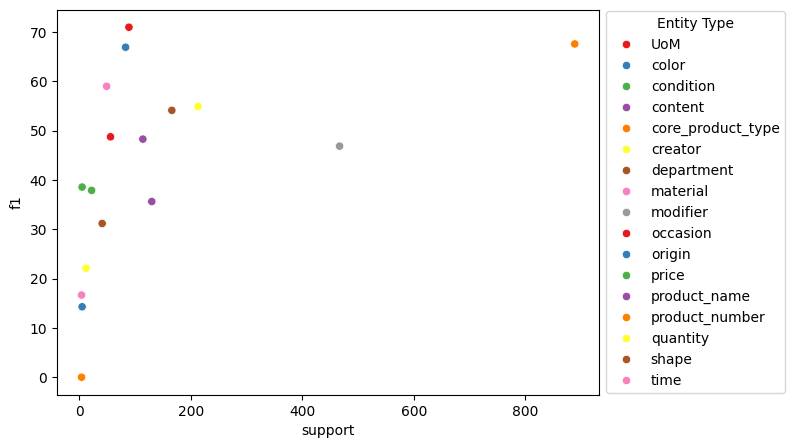

In [210]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_entities[(df_entities["crf_type"]=="crf")].groupby("entity").agg({"f1": "mean", "precision": "mean", "recall": "mean", "support": "max"}).reset_index(),
    x="support",
    y="f1",
    hue="entity",
    palette="Set1"
)
plt.legend(title="Entity Type", loc="center left", bbox_to_anchor=(1, 0.5))

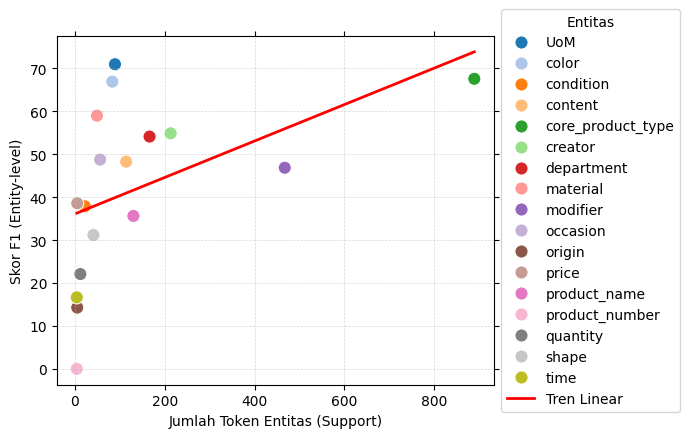

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_plot = (
    df_entities[df_entities["crf_type"]=="crf"]
    .groupby("entity")
    .agg({"f1": "mean", "precision": "mean", "recall": "mean", "support": "max"})
    .reset_index()
)

palette = sns.color_palette("tab20", n_colors=df_plot["entity"].nunique())

plt.figure(figsize=(7,4.5))

ax = sns.scatterplot(
    data=df_plot,
    x="support",
    y="f1",
    hue="entity",
    palette=palette,
    s=90
)

# garis tren linear
x = df_plot["support"].values
y = df_plot["f1"].values

coef = np.polyfit(x, y, 1)          # slope dan intercept
poly1d_fn = np.poly1d(coef)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = poly1d_fn(x_line)

plt.plot(
    x_line,
    y_line,
    color="red",
    linewidth=2,
    label="Tren Linear"
)

ax.set_xlabel("Jumlah Token Entitas (Support)")
ax.set_ylabel("Skor F1 (Entity-level)")

ax.tick_params(axis="x", top=True, bottom=True)
ax.tick_params(axis="y", left=True, right=True)

ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.legend(
    title="Entitas",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

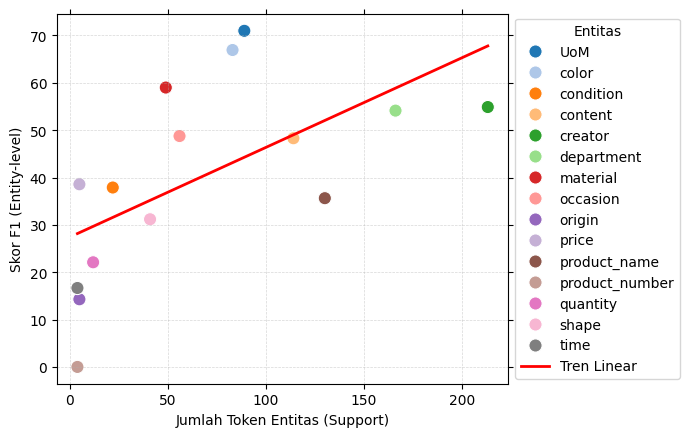

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# buang entitas yang ingin dikecualikan
df_plot = (
    df_entities[
        (df_entities["crf_type"] == "crf") &
        (~df_entities["entity"].isin(["modifier", "core_product_type"]))
    ]
    .groupby("entity")
    .agg({
        "f1": "mean",
        "precision": "mean",
        "recall": "mean",
        "support": "max"
    })
    .reset_index()
)

palette = sns.color_palette("tab20", n_colors=df_plot["entity"].nunique())

plt.figure(figsize=(7,4.5))

ax = sns.scatterplot(
    data=df_plot,
    x="support",
    y="f1",
    hue="entity",
    palette=palette,
    s=90
)

# hitung ulang garis tren setelah modifier dan core_product_type dibuang
x = df_plot["support"].values
y = df_plot["f1"].values

coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = poly1d_fn(x_line)

plt.plot(
    x_line,
    y_line,
    color="red",
    linewidth=2,
    label="Tren Linear"
)

ax.set_xlabel("Jumlah Token Entitas (Support)")
ax.set_ylabel("Skor F1 (Entity-level)")

ax.tick_params(axis="x", top=True, bottom=True)
ax.tick_params(axis="y", left=True, right=True)

ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.legend(
    title="Entitas",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

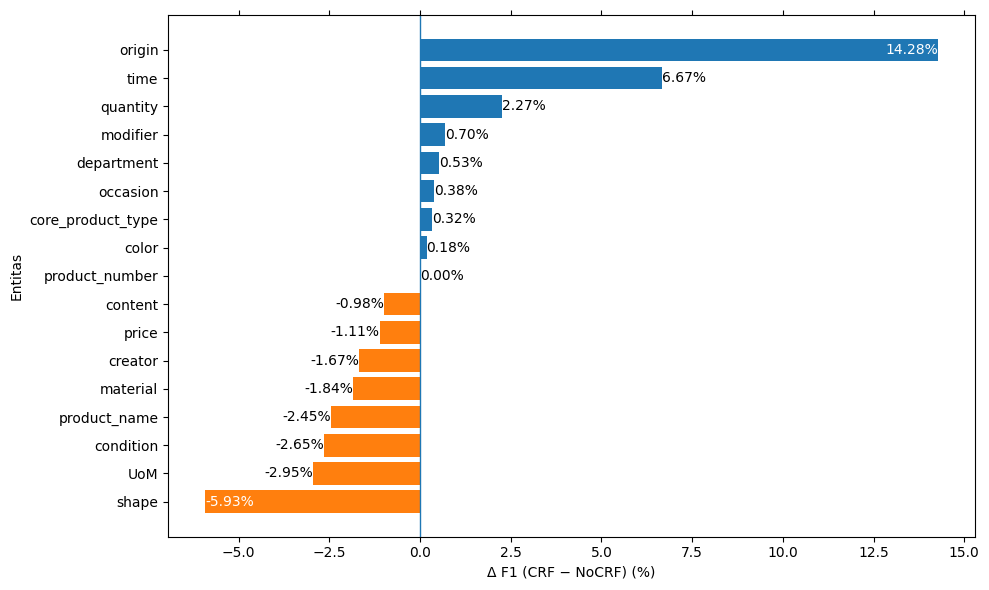

In [44]:
import matplotlib.pyplot as plt

data = (entity_crf_compare["delta_crf"].sort_values()).round(2)

fig, ax = plt.subplots(figsize=(10,6))

colors = ["tab:blue" if v > 0 else "tab:orange" for v in data]

bars = ax.barh(data.index, data.values, color=colors)

# entity yang teksnya mau di dalam bar
inside_entities = ["origin", "shape"]

for i, (entity, v) in enumerate(data.items()):
    
    if entity in inside_entities:
        if v >= 0:
            ax.text(v - 0.002, i, f"{v:.2f}%", va="center", ha="right", color="white")
        else:
            ax.text(v + 0.002, i, f"{v:.2f}%", va="center", ha="left", color="white")
    
    else:
        if v >= 0:
            ax.text(v + 0.002, i, f"{v:.2f}%", va="center")
        else:
            ax.text(v - 0.002, i, f"{v:.2f}%", va="center", ha="right")

ax.axvline(0, linewidth=1)

ax.tick_params(axis='x', top=True, bottom=True)

ax.set_xlabel("Δ F1 (CRF − NoCRF) (%)")
ax.set_ylabel("Entitas")

plt.tight_layout()
plt.show()

In [73]:
def categorize_entity(support):
    if support <= 50:
        return "rare"
    elif support <= 200:
        return "medium"
    else:
        return "frequent"
    
df_entities["entity_category"] = df_entities["support"].apply(categorize_entity)

Text(0.5, 0, 'Entity Category')

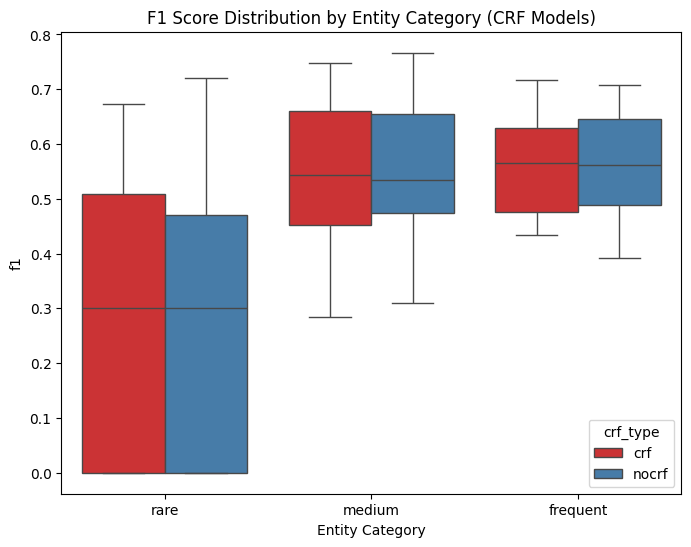

In [86]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_entities,
    x="entity_category",
    y="f1",
    palette="Set1",
    hue="crf_type",
    order=["rare", "medium", "frequent"]
)
plt.title("F1 Score Distribution by Entity Category (CRF Models)")
plt.xlabel("Entity Category")

In [92]:
df_entities[(df_entities["crf_type"]=="crf")].groupby("entity_category").aggregate({
    "f1": "median",
})

,f1
entity_category,
frequent,0.564478
medium,0.542699
rare,0.300161


In [142]:
df_category_compare = (
    df_entities
    .groupby(["entity_category", "crf_type"])["f1"]
    .mean()
    .unstack()
)

df_category_compare["delta_crf"] = df_category_compare["crf"] - df_category_compare["nocrf"]

(df_category_compare).round(2)

crf_type,crf,nocrf,delta_crf
entity_category,,,
frequent,56.45,56.67,-0.22
medium,54.12,55.00,-0.88
rare,27.46,26.00,1.46


C:\Users\user\AppData\Local\Temp\ipykernel_22428\1340358225.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


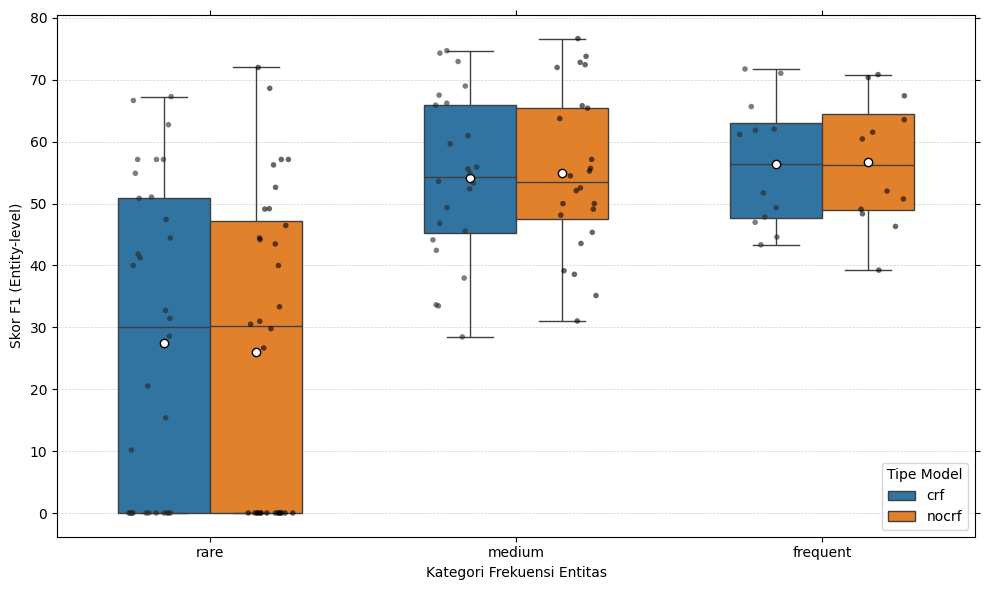

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(10,6))

# BOX PLOT
ax = sns.boxplot(
    data=df_entities,
    x="entity_category",
    y="f1",
    hue="crf_type",
    order=["rare","medium","frequent"],
    palette={"crf":"tab:blue","nocrf":"tab:orange"},
    width=0.6,
    showmeans=True,
    meanprops={
        "marker":"o",
        "markerfacecolor":"white",
        "markeredgecolor":"black",
        "markersize":6
    }
)

# STRIP PLOT (titik entity individual)
sns.stripplot(
    data=df_entities,
    x="entity_category",
    y="f1",
    hue="crf_type",
    order=["rare","medium","frequent"],
    dodge=True,
    jitter=0.15,
    color="black",
    alpha=0.6,
    size=4
)

# axis labels
ax.set_xlabel("Kategori Frekuensi Entitas")
ax.set_ylabel("Skor F1 (Entity-level)")

# format persen
# ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# grid horizontal
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# tick atas bawah
ax.tick_params(axis="x", top=True, bottom=True)
ax.tick_params(axis="y", left=True, right=True)

# FIX legend (karena stripplot bikin legend dobel)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Tipe Model", loc="lower right")

plt.tight_layout()
plt.show()

In [79]:
# print each entity category and its entity names, prevent duplicate entity names by using set, add the support number for each entity
for category in df_entities["entity_category"].unique():
    entities_in_category = df_entities[df_entities["entity_category"] == category]["entity"].unique()
    print(f"{category.capitalize()} Entities (Support <= {50 if category == 'rare' else 200 if category == 'medium' else '>'}):")
    for entity in entities_in_category:
        support = df_entities[df_entities["entity"] == entity]["support"].max()
        print(f"  - {entity} (Support: {support})")
    print("==" * 20)

Medium Entities (Support <= 200):
  - UoM (Support: 89)
  - color (Support: 83)
  - content (Support: 114)
  - department (Support: 166)
  - occasion (Support: 56)
  - product_name (Support: 130)
Rare Entities (Support <= 50):
  - condition (Support: 22)
  - material (Support: 49)
  - origin (Support: 5)
  - price (Support: 5)
  - product_number (Support: 4)
  - quantity (Support: 12)
  - shape (Support: 41)
  - time (Support: 4)
Frequent Entities (Support <= >):
  - core_product_type (Support: 889)
  - creator (Support: 213)
  - modifier (Support: 467)


### Qualitative

In [154]:
def has_invalid_bio(labels):
    prev_tag = "O"
    
    for label in labels:
        if label.startswith("I-"):
            entity = label[2:]
            
            if prev_tag == "O" or prev_tag[2:] != entity:
                return True
                
        prev_tag = label
        
    return False

In [168]:
def crf_fix_prediction(gold, nocrf, crf):
    return nocrf != gold and crf == gold

def boundary_error(gold, pred):
    return gold != pred

In [184]:
invalid_bio_examples = []

for i, item in enumerate(results_label):

    tokens = item["tokens"]
    gold = item["gold"]
    pred_crf = item["bilstm-crf"]
    pred_nocrf = item["bilstm-nocrf"]

    if has_invalid_bio(pred_nocrf) and not has_invalid_bio(pred_crf):

        invalid_bio_examples.append({
            "index": i,
            "tokens": tokens,
            "gold": gold,
            "nocrf": pred_nocrf,
            "crf": pred_crf
        })

    if len(invalid_bio_examples) >= 50:
        break

In [185]:
boundary_examples = []

for i, item in enumerate(results_label):

    tokens = item["tokens"]
    gold = item["gold"]
    pred_crf = item["bilstm-crf"]
    pred_nocrf = item["bilstm-nocrf"]

    if boundary_error(gold, pred_nocrf) and not boundary_error(gold, pred_crf):

        boundary_examples.append({
            "index": i,
            "tokens": tokens,
            "gold": gold,
            "nocrf": pred_nocrf,
            "crf": pred_crf
        })

    if len(boundary_examples) >= 50:
        break

In [186]:
fix_examples = []

for i, item in enumerate(results_label):

    tokens = item["tokens"]
    gold = item["gold"]
    pred_crf = item["bilstm-crf"]
    pred_nocrf = item["bilstm-nocrf"]

    if crf_fix_prediction(gold, pred_nocrf, pred_crf):

        fix_examples.append({
            "index": i,
            "tokens": tokens,
            "gold": gold,
            "nocrf": pred_nocrf,
            "crf": pred_crf
        })

    if len(fix_examples) >= 50:
        break

In [187]:
def print_examples(examples):

    for ex in examples:

        print("\nExample", ex["index"])

        print("Tokens :", " | ".join(ex["tokens"]))
        print("Gold   :", " | ".join(ex["gold"]))
        print("NoCRF  :", " | ".join(ex["nocrf"]))
        print("CRF    :", " | ".join(ex["crf"]))

In [ ]:
# print_examples(invalid_bio_examples)


Example 2
Tokens : cascade | platinum | dishwasher | pods
Gold   : B-creator | B-product_name | B-core_product_type | I-core_product_type
NoCRF  : B-creator | B-product_name | I-modifier | I-core_product_type
CRF    : B-creator | I-creator | B-core_product_type | I-core_product_type

Example 8
Tokens : yarn | swift | carrying | case
Gold   : B-modifier | I-modifier | B-core_product_type | I-core_product_type
NoCRF  : B-core_product_type | I-modifier | B-core_product_type | I-core_product_type
CRF    : B-core_product_type | B-modifier | O | B-core_product_type

Example 10
Tokens : 75 | ft | telephone | cords | for | landline | phones
Gold   : B-UoM | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier
NoCRF  : B-product_name | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier
CRF    : B-UoM | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier

Example 12
Tokens : kids | usa

In [ ]:
# print_examples(boundary_examples)


Example 6
Tokens : womens | high | wasted | workout | shorts
Gold   : B-department | B-modifier | I-modifier | B-core_product_type | I-core_product_type
NoCRF  : B-department | B-shape | I-shape | B-occasion | B-core_product_type
CRF    : B-department | B-modifier | I-modifier | B-core_product_type | I-core_product_type

Example 10
Tokens : 75 | ft | telephone | cords | for | landline | phones
Gold   : B-UoM | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier
NoCRF  : B-product_name | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier
CRF    : B-UoM | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier

Example 29
Tokens : two | yr | old | girls | toys
Gold   : B-department | I-department | I-department | B-department | B-core_product_type
NoCRF  : B-core_product_type | I-department | I-department | B-department | B-core_product_type
CRF    : B-department | I-department | 

In [ ]:
# print_examples(fix_examples)


Example 6
Tokens : womens | high | wasted | workout | shorts
Gold   : B-department | B-modifier | I-modifier | B-core_product_type | I-core_product_type
NoCRF  : B-department | B-shape | I-shape | B-occasion | B-core_product_type
CRF    : B-department | B-modifier | I-modifier | B-core_product_type | I-core_product_type

Example 10
Tokens : 75 | ft | telephone | cords | for | landline | phones
Gold   : B-UoM | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier
NoCRF  : B-product_name | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier
CRF    : B-UoM | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier

Example 29
Tokens : two | yr | old | girls | toys
Gold   : B-department | I-department | I-department | B-department | B-core_product_type
NoCRF  : B-core_product_type | I-department | I-department | B-department | B-core_product_type
CRF    : B-department | I-department | 

In [ ]:
# examples = []

# for i, item in enumerate(results_label):
    
#     tokens = item["tokens"]
#     gold = item["gold"]
#     pred_crf = item["bilstm-crf"]
#     pred_nocrf = item["bilstm-nocrf"]
    
#     if has_invalid_bio(pred_nocrf) and not has_invalid_bio(pred_crf):
#         examples.append({
#             "index": i,
#             "tokens": tokens,
#             "gold": gold,
#             "nocrf": pred_nocrf,
#             "crf": pred_crf
#         })
        
#     if len(examples) >= 100:
#         break

In [ ]:
# for ex in examples:
    
#     print(f"\nExample {ex['index']}")
    
#     print("Tokens :", " | ".join(ex["tokens"]))
#     print("Gold   :", " | ".join(ex["gold"]))
#     print("NoCRF  :", " | ".join(ex["nocrf"]))
#     print("CRF    :", " | ".join(ex["crf"]))


Example 2
Tokens : cascade | platinum | dishwasher | pods
Gold   : B-creator | B-product_name | B-core_product_type | I-core_product_type
NoCRF  : B-creator | B-product_name | I-modifier | I-core_product_type
CRF    : B-creator | I-creator | B-core_product_type | I-core_product_type

Example 8
Tokens : yarn | swift | carrying | case
Gold   : B-modifier | I-modifier | B-core_product_type | I-core_product_type
NoCRF  : B-core_product_type | I-modifier | B-core_product_type | I-core_product_type
CRF    : B-core_product_type | B-modifier | O | B-core_product_type

Example 10
Tokens : 75 | ft | telephone | cords | for | landline | phones
Gold   : B-UoM | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier
NoCRF  : B-product_name | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier
CRF    : B-UoM | I-UoM | B-core_product_type | I-core_product_type | B-modifier | I-modifier | I-modifier

Example 12
Tokens : kids | usa

In [156]:
examples_fix = []

for i in range(len(gold_labels)):
    
    gold = gold_labels[i]
    pred_crf = pred_labels["bilstm-crf"][i]
    pred_nocrf = pred_labels["bilstm-nocrf"][i]
    
    if pred_nocrf != gold and pred_crf == gold:
        examples_fix.append((i, gold, pred_nocrf, pred_crf))
        
    if len(examples_fix) >= 10:
        break

In [157]:
examples_fix

[(6,
  ['B-department',
   'B-modifier',
   'I-modifier',
   'B-core_product_type',
   'I-core_product_type'],
  ['B-department', 'B-shape', 'I-shape', 'B-occasion', 'B-core_product_type'],
  ['B-department',
   'B-modifier',
   'I-modifier',
   'B-core_product_type',
   'I-core_product_type']),
 (10,
  ['B-UoM',
   'I-UoM',
   'B-core_product_type',
   'I-core_product_type',
   'B-modifier',
   'I-modifier',
   'I-modifier'],
  ['B-product_name',
   'I-UoM',
   'B-core_product_type',
   'I-core_product_type',
   'B-modifier',
   'I-modifier',
   'I-modifier'],
  ['B-UoM',
   'I-UoM',
   'B-core_product_type',
   'I-core_product_type',
   'B-modifier',
   'I-modifier',
   'I-modifier']),
 (29,
  ['B-department',
   'I-department',
   'I-department',
   'B-department',
   'B-core_product_type'],
  ['B-core_product_type',
   'I-department',
   'I-department',
   'B-department',
   'B-core_product_type'],
  ['B-department',
   'I-department',
   'I-department',
   'B-department',
   'B-co

### Heatmap

In [12]:
def create_heatmap_data(gold_labels, pred_labels, label_info):
    labels = list(label_info["id2label"].values())
    label_to_index = {label: idx for idx, label in enumerate(labels)}
    
    num_labels = len(labels)
    confusion_matrix = [[0] * num_labels for _ in range(num_labels)]
    
    for gold_seq, pred_seq in zip(gold_labels, pred_labels):
        for gold_label, pred_label in zip(gold_seq, pred_seq):
            gold_idx = label_to_index[gold_label]
            pred_idx = label_to_index[pred_label]
            confusion_matrix[gold_idx][pred_idx] += 1
            
    return labels, confusion_matrix

In [13]:
labels, cm = create_heatmap_data(gold_labels, pred_labels["bilstm-crf"], label_info)

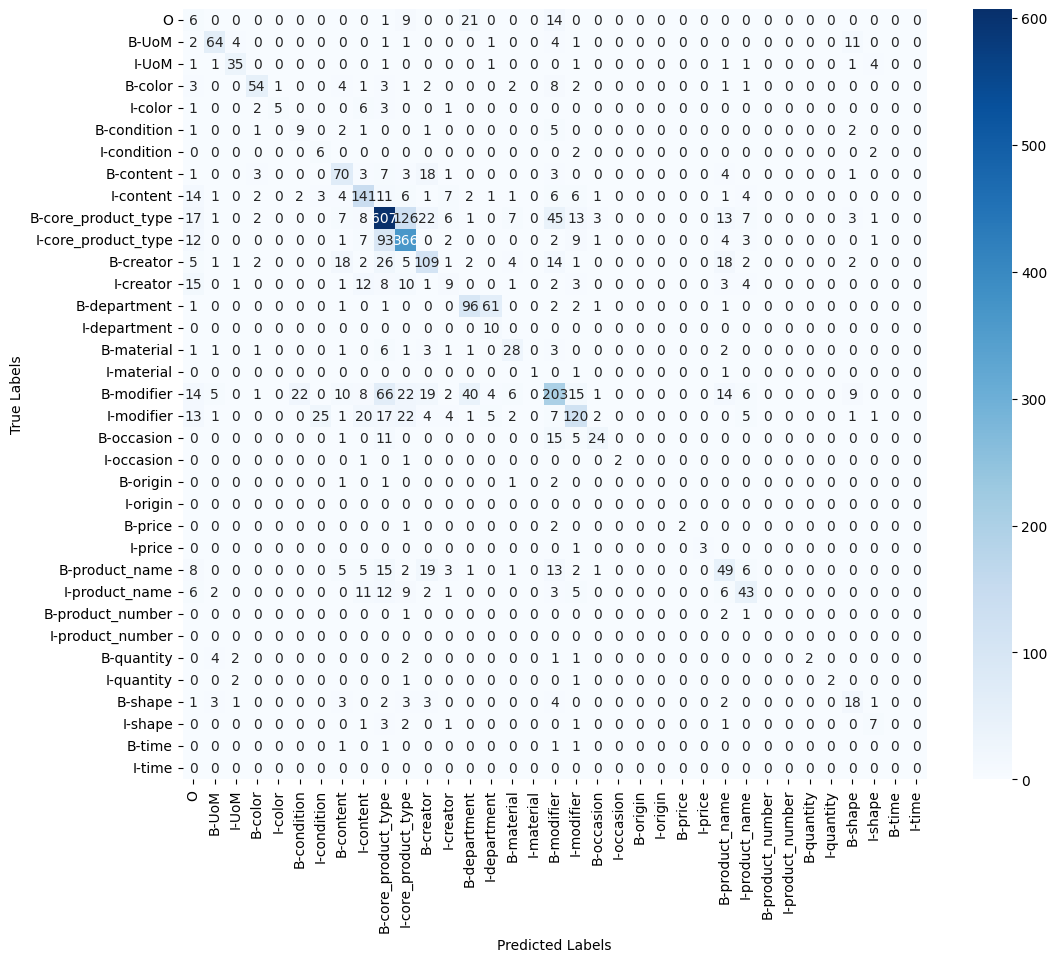

In [15]:
def print_cm_using_plt(labels, cm):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    # plt.title('Confusion Matrix')
    plt.show()

print_cm_using_plt(labels, cm)

In [22]:
def print_cm_using_plt(labels, cm):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(14, 12), dpi=300)

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 10},   # kecil tapi masih kebaca
        cbar_kws={"shrink": 0.8}
    )

    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)

    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)

    # plt.title('Confusion Matrix', fontsize=14)

    plt.tight_layout()
    plt.show()

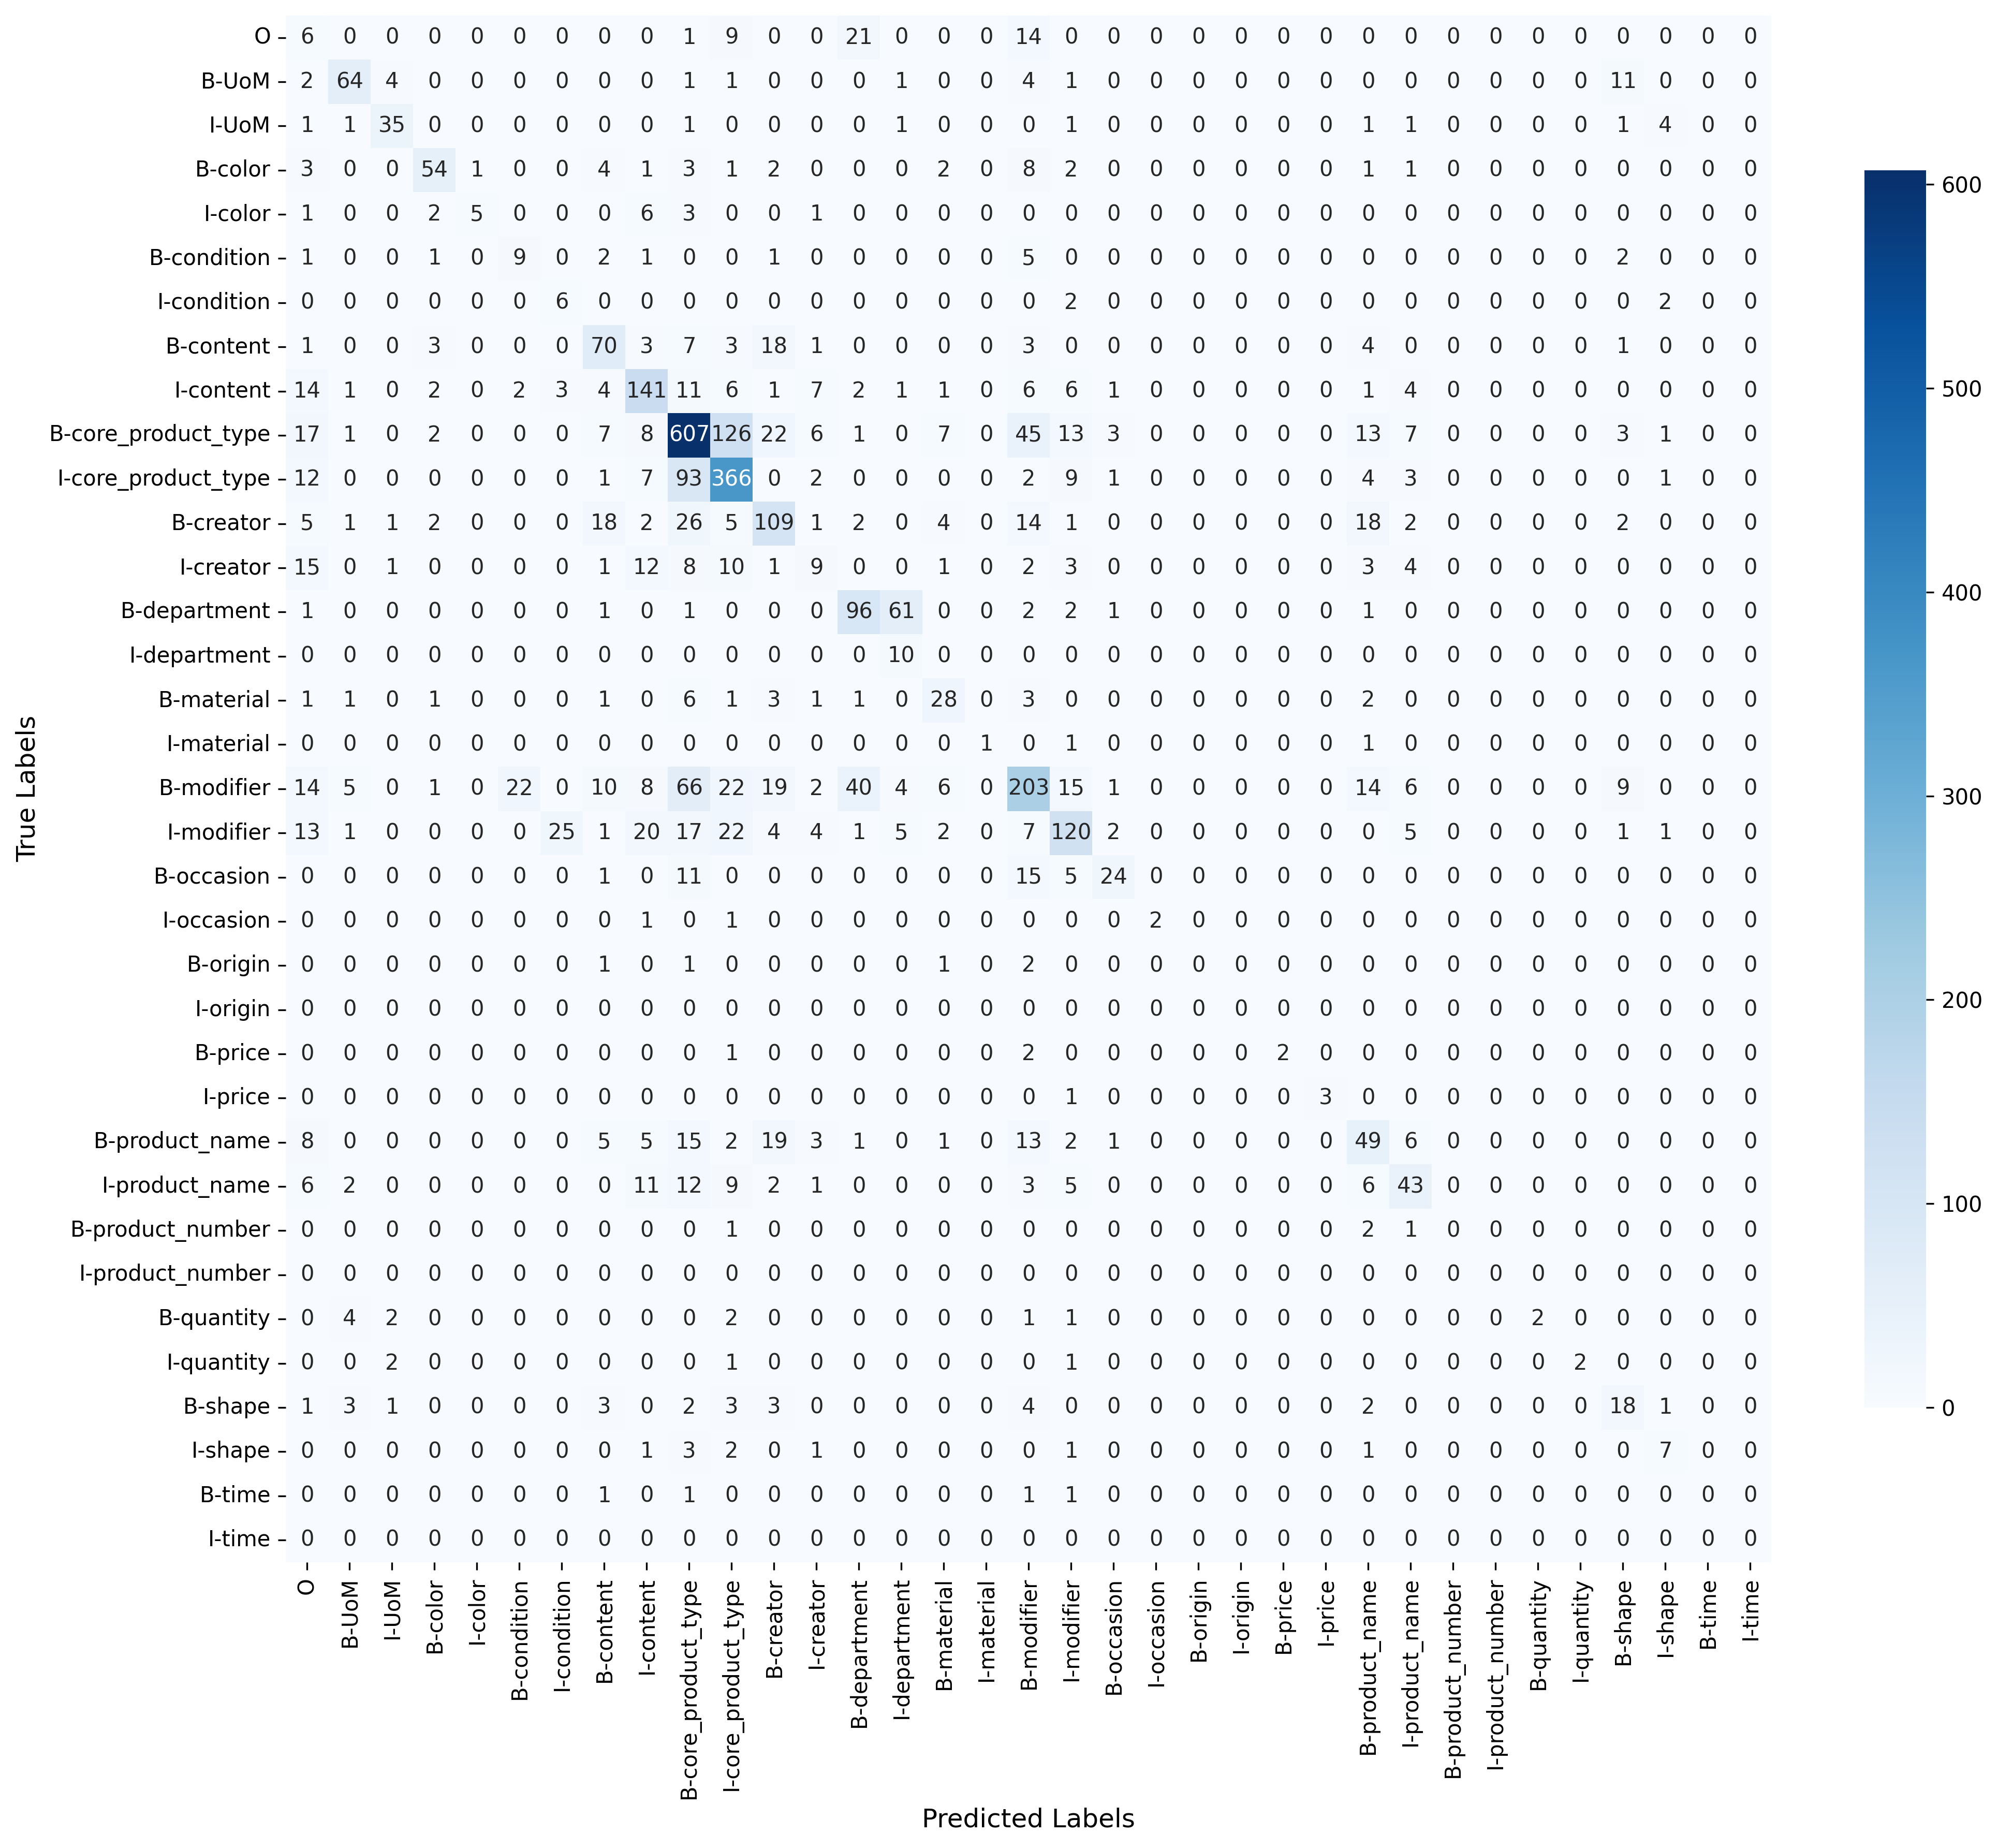

In [23]:
print_cm_using_plt(labels, cm)